# Plaque visualization

- Per-class annotation grid (random examples)
- Normalization + augmentation overview (from former `plaque_dataset` `__main__`)
- Export two plaques: one normalized + three augmented PNGs each

In [7]:
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms as trf

# Repo root: parent of notebooks/ when this notebook lives under notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
REPO_ROOT = os.getcwd()
SRC = os.path.join(REPO_ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from models.config import Config
from models.data.plaque_dataset import PlaqueDataset
from semi_supervised_runner import SemiSupervisedRunner
from utils.data_utils import load_data_df

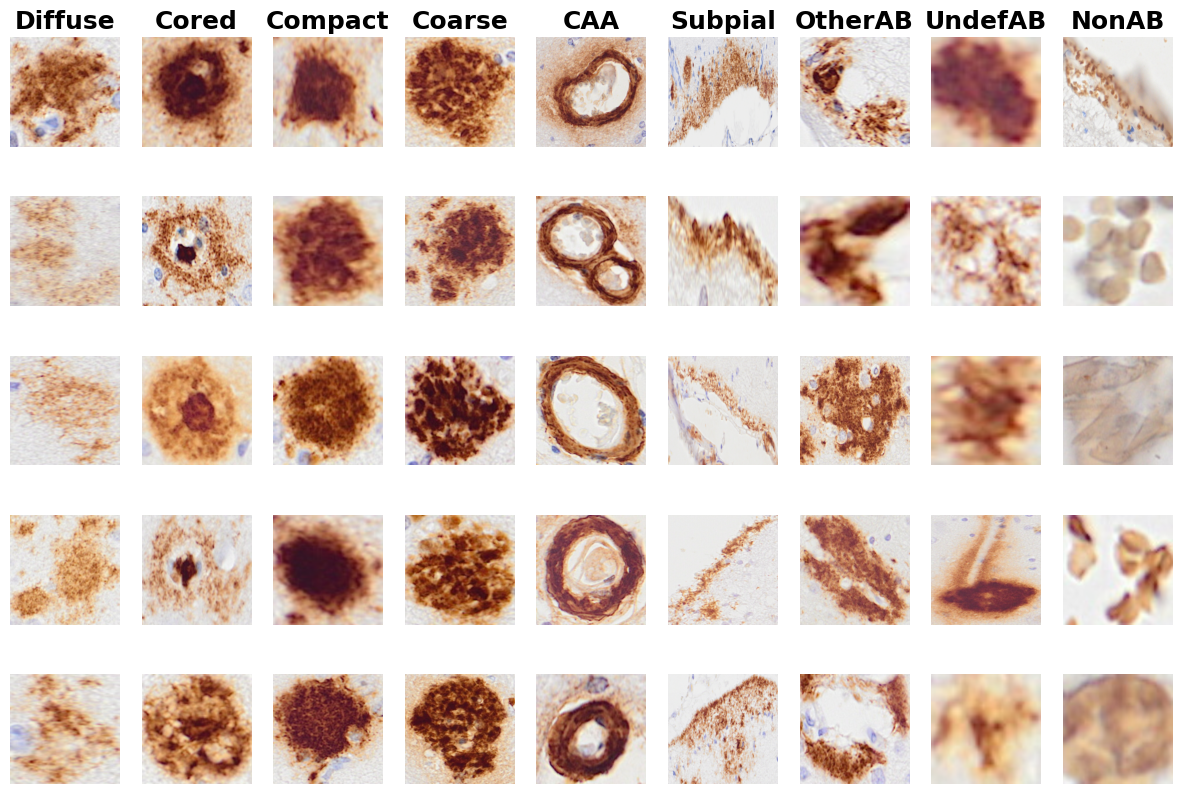

In [8]:
NUM_EXAMPLES = 5
labels = [
    "Diffuse",
    "Cored",
    "Compact",
    "Coarse",
    "CAA",
    "Subpial",
    "OtherAB",
    "UndefAB",
    "NonAB",
]
fig, axs = plt.subplots(NUM_EXAMPLES, len(labels), figsize=(15, 10))

np.random.seed(44)
for i, label in enumerate(labels):
    image_files = np.random.permutation(
        os.listdir(os.path.join("data/labeled_images", label))
    )
    for j, image_path in enumerate(image_files[:NUM_EXAMPLES]):
        img_full_path = os.path.join("data/labeled_images", label, image_path)
        raw_image_pil = (
            Image.open(img_full_path).convert("RGB").resize((224, 224), Image.BILINEAR)
        )
        axs[j, i].imshow(raw_image_pil)
        if j == 0:
            axs[j, i].set_title(label, fontsize=18, fontweight="bold")
        axs[j, i].set_xticks([])
        axs[j, i].set_yticks([])
        axs[j, i].set_xlabel("", fontsize=14, fontweight="bold")
        axs[j, i].set_ylabel("", fontsize=14, fontweight="bold")
        axs[j, i].axis("off")

out_annot = os.path.join(REPO_ROOT, "notebooks", "plaques_annotation_visualization.png")
plt.savefig(out_annot, bbox_inches="tight")
plt.show()

labeled_data_df shape: (589, 5)


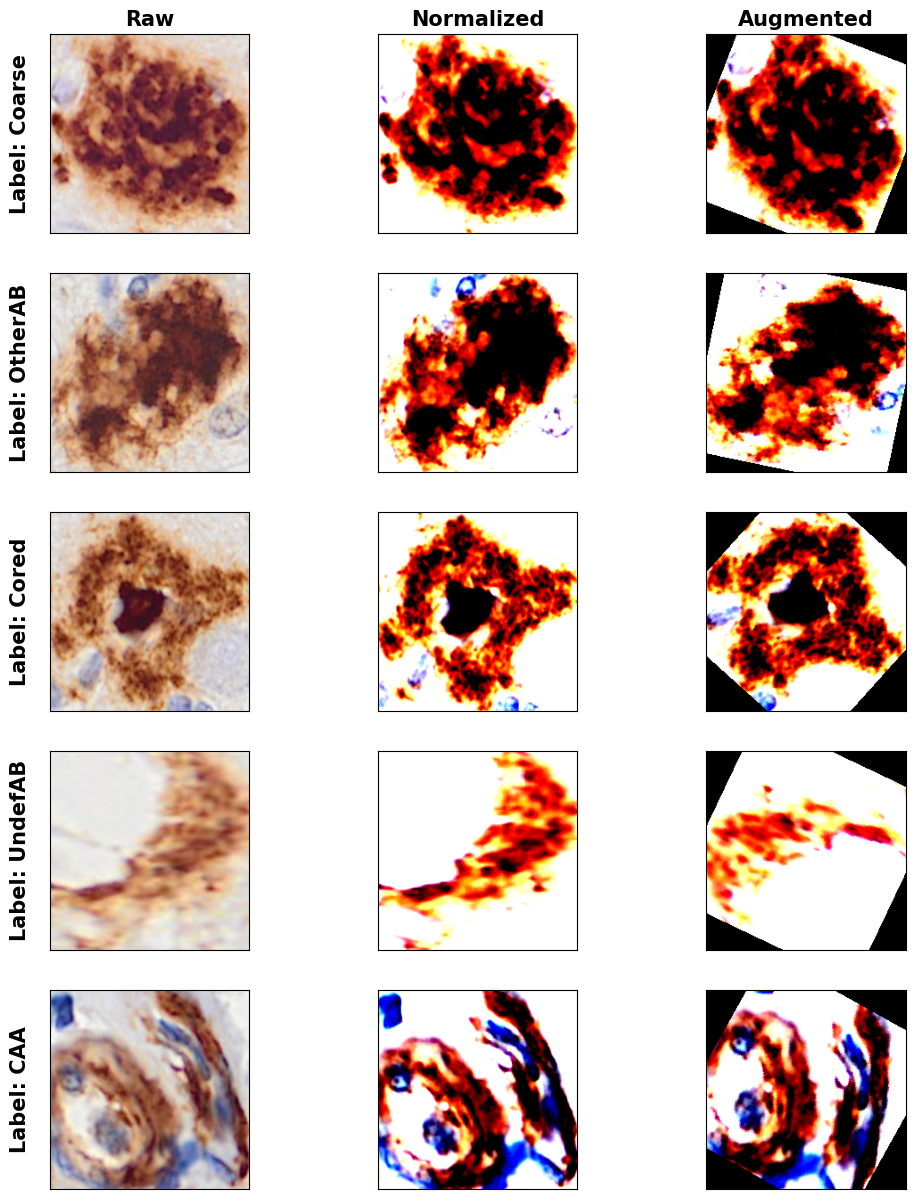

In [20]:
config = Config.load_config("configs", "supervised", "single")

data_df_path = os.path.join(
    config.general_config.data.data_folder,
    config.general_config.data.data_table_file_name,
)
labeled_data_df, unlabeled_data_df = load_data_df(
    data_df_path=data_df_path,
    labeled_sample_size=config.general_config.data.labeled_sample_size,
    unlabeled_sample_size=config.general_config.data.unlabeled_sample_size,
    train_mode="self_supervised",
)
print("labeled_data_df shape:", labeled_data_df.shape)

labeled_data_folder_path = os.path.join(
    config.general_config.data.data_folder,
    config.general_config.data.labeled_data_folder,
)

sample_indices = list(range(min(8, len(labeled_data_df))))
sample_df = labeled_data_df.iloc[sample_indices]

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

aug_transform = trf.Compose(
    [
        trf.RandomHorizontalFlip(p=0.5),
        trf.RandomVerticalFlip(p=0.5),
        trf.RandomRotation(degrees=90),
        trf.ColorJitter(brightness=0.2, contrast=0.2),
        trf.ToTensor(),
    ]
)

ds_normalized = PlaqueDataset(
    sample_df,
    labeled_data_folder_path,
    name_to_label=config.name_to_label,
    transforms=[trf.ToTensor()],
    preload=False,
    description="labeled images (normalized only)",
    normalize_data=True,
    normalize_mean=config.general_config.data.normalize_mean,
    normalize_std=config.general_config.data.normalize_std,
)

ds_augmented = PlaqueDataset(
    sample_df,
    labeled_data_folder_path,
    name_to_label=config.name_to_label,
    transforms=aug_transform,
    preload=False,
    description="labeled images (augmented)",
    normalize_data=True,
    normalize_mean=config.general_config.data.normalize_mean,
    normalize_std=config.general_config.data.normalize_std,
)

LIMIT = min(5, len(ds_normalized))
fig, axes = plt.subplots(LIMIT, 3, figsize=(12, LIMIT * 3))
if LIMIT == 1:
    axes = np.expand_dims(axes, axis=0)

axes[0, 0].set_title("Raw", fontsize=15, fontweight="bold")
axes[0, 1].set_title("Normalized", fontsize=15, fontweight="bold")
axes[0, 2].set_title("Augmented", fontsize=15, fontweight="bold")

for i in range(LIMIT):
    (
        image_path,
        normalized_raw_image_tensor,
        normalized_transformed_image_tensors,
        _extra_features,
        label,
    ) = ds_normalized[i]

    raw_pil = Image.open(image_path).convert("RGB").resize(
        config.general_config.data.downscaled_image_size, Image.BILINEAR
    )
    raw_image_np = np.array(raw_pil).clip(0, 255) / 255.0

    normalized_raw_image_np = (
        normalized_raw_image_tensor.permute(1, 2, 0).detach().cpu().numpy().clip(0, 1)
    )

    (
        _aug_image_path,
        _aug_norm_raw,
        aug_stack,
        _ef,
        _lab,
    ) = ds_augmented[i]
    aug_img_tensor = aug_stack[0]
    norm_aug_np = aug_img_tensor.permute(1, 2, 0).detach().cpu().numpy().clip(0, 1)

    axes[i, 0].imshow(raw_image_np)
    axes[i, 1].imshow(normalized_raw_image_np)
    axes[i, 2].imshow(norm_aug_np)

    label_name = (
        config.label_to_name[label] if label in config.label_to_name else str(label)
    )
    axes[i, 0].text(
        -0.10,
        0.5,
        f"Label: {label_name}",
        transform=axes[i, 0].transAxes,
        fontsize=15,
        va="center",
        ha="right",
        rotation=90,
        fontweight="bold",
    )
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])

# plt.tight_layout()
# out_norm = os.path.join(REPO_ROOT, "notebooks", "plaque_normalization_augmentation_visualization.png")
# plt.savefig(out_norm)
# plt.show()

In [21]:
def _save_chw_tensor_png(tensor_chw: torch.Tensor, path: str) -> None:
    arr = tensor_chw.permute(1, 2, 0).detach().cpu().numpy()
    arr = np.clip(arr, 0.0, 1.0)
    img = np.round(arr * 255.0).astype(np.uint8)
    Image.fromarray(img).save(path)


export_parent = os.path.join(REPO_ROOT, "notebooks")
plaque_indices = [1, 4]
for folder_idx, sample_i in enumerate(plaque_indices):
    if sample_i >= len(ds_normalized):
        raise IndexError(
            f"sample index {sample_i} out of range for ds_normalized (len={len(ds_normalized)})"
        )
    out_dir = os.path.join(export_parent, f"plaque_export_{folder_idx}")
    os.makedirs(out_dir, exist_ok=True)

    _path, norm_tensor, _stack, _ef, _lab = ds_normalized[sample_i]
    _save_chw_tensor_png(norm_tensor, os.path.join(out_dir, "normalized.png"))

    for k in range(3):
        _p2, _nr, aug_stack, _e2, _l2 = ds_augmented[sample_i]
        _save_chw_tensor_png(aug_stack[0], os.path.join(out_dir, f"augmented_{k + 1}.png"))

    print("Wrote:", out_dir)

Wrote: /Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/notebooks/plaque_export_0
Wrote: /Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/notebooks/plaque_export_1


Seed set to 44
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Random seeds set to 44 for reproducibility
torch.Size([2, 3, 224, 224])


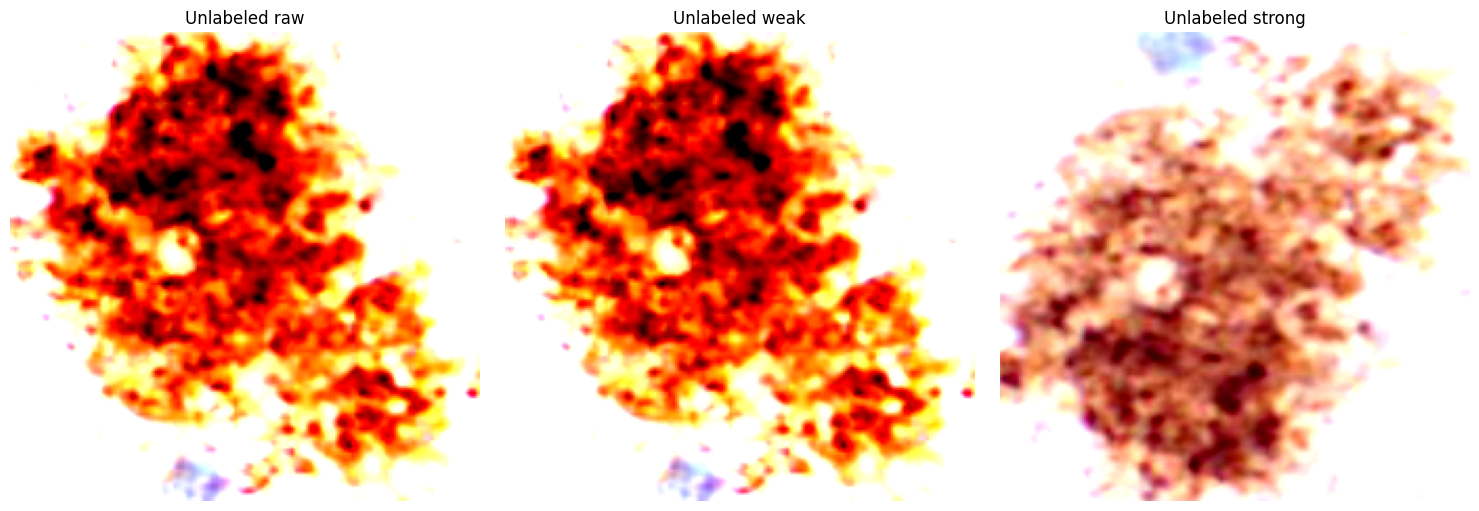

Saved weak/strong example from: data/sampled_unlabeled_images/2012-060_Tpole_AB_Image_index_20665.png
Output folder: /Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/notebooks/unlabeled_weak_strong_example


In [38]:
# Last cell: use SemiSupervisedRunner and save one unlabeled weak/strong example

config = Config.load_config("configs", "semi_supervised", "single")
runner = SemiSupervisedRunner(config, "single", save_config=False)

seed = config.general_config.system.random_seed
train_df, test_df = train_test_split(
    runner.labeled_data_df,
    test_size=config.general_config.training.test_size,
    stratify=runner.labeled_data_df["Label"],
    random_state=seed,
)
train_df, val_df = train_test_split(
    train_df,
    test_size=config.general_config.training.val_size
    / (1 - config.general_config.training.test_size),
    stratify=train_df["Label"],
    random_state=seed,
)

(
    _train_labeled_loader,
    _val_labeled_loader,
    _test_labeled_loader,
    train_unlabeled_loader,
) = runner.load_dataloaders(train_df, val_df, test_df, runner.unlabeled_data_df)

ds_unlabeled = train_unlabeled_loader.dataset


def denormalize_tensor(tensor_chw, mean, std):
    mean_t = torch.tensor(mean, dtype=tensor_chw.dtype).view(-1, 1, 1)
    std_t = torch.tensor(std, dtype=tensor_chw.dtype).view(-1, 1, 1)
    return tensor_chw * std_t + mean_t


def save_chw_tensor_png(tensor_chw, path):
    arr = tensor_chw.permute(1, 2, 0).detach().cpu().numpy()
    arr = np.clip(arr, 0.0, 1.0)
    img = np.round(arr * 255.0).astype(np.uint8)
    Image.fromarray(img).save(path)


unlabeled_idx = 4
img_path, normalized_raw_tensor, weak_strong_stack, _ef, _label = ds_unlabeled[unlabeled_idx]
weak_tensor = weak_strong_stack[0]
strong_tensor = weak_strong_stack[1]
print(weak_strong_stack.shape)

mean = config.general_config.data.normalize_mean
std = config.general_config.data.normalize_std

# raw_for_vis = denormalize_tensor(normalized_raw_tensor, mean, std).clamp(0, 1)
# weak_for_vis = denormalize_tensor(weak_tensor, mean, std).clamp(0, 1)
# strong_for_vis = denormalize_tensor(strong_tensor, mean, std).clamp(0, 1)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(normalized_raw_tensor.permute(1, 2, 0).cpu().numpy())
axs[0].set_title("Unlabeled raw")
axs[0].axis("off")

axs[1].imshow(weak_tensor.permute(1, 2, 0).cpu().numpy())
axs[1].set_title("Unlabeled weak")
axs[1].axis("off")

axs[2].imshow(strong_tensor.permute(1, 2, 0).cpu().numpy())
axs[2].set_title("Unlabeled strong")
axs[2].axis("off")

plt.tight_layout()
plot_path = os.path.join(REPO_ROOT, "notebooks", "unlabeled_weak_strong_aug_example.png")
plt.savefig(plot_path)
plt.show()

weak_strong_dir = os.path.join(REPO_ROOT, "notebooks", "unlabeled_weak_strong_example")
os.makedirs(weak_strong_dir, exist_ok=True)

save_chw_tensor_png(normalized_raw_tensor, os.path.join(weak_strong_dir, "unlabeled_raw.png"))
save_chw_tensor_png(weak_tensor, os.path.join(weak_strong_dir, "unlabeled_weak.png"))
save_chw_tensor_png(strong_tensor, os.path.join(weak_strong_dir, "unlabeled_strong.png"))

print("Saved weak/strong example from:", img_path)
print("Output folder:", weak_strong_dir)

In [39]:
examples = np.array([3,5,7,9,15])
for i in examples:
    img_path, normalized_raw_tensor, weak_strong_stack, _ef, _label = ds_unlabeled[i]
    weak_tensor = weak_strong_stack[0]
    strong_tensor = weak_strong_stack[1]
    # Save weak/strong tensors as PNGs
    save_chw_tensor_png(weak_tensor, os.path.join(weak_strong_dir, f"weak_tensor_{i}.png"))
    save_chw_tensor_png(strong_tensor, os.path.join(weak_strong_dir, f"strong_tensor_{i}.png"))
    print(f"Saved weak/strong tensors for example {i}")

print("Saved all weak/strong tensors to:", weak_strong_dir)


Saved weak/strong tensors for example 3
Saved weak/strong tensors for example 5
Saved weak/strong tensors for example 7
Saved weak/strong tensors for example 9
Saved weak/strong tensors for example 15
Saved all weak/strong tensors to: /Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/notebooks/unlabeled_weak_strong_example
